# Tabulated proton and neutron densities

This notebook demonstrates the packaged density tables exposed through `jitr.utils.density`. The tables provide proton and neutron densities for specific `(A, Z)` targets in two density models, which can be interpolated onto any radial grid.

The densitiea are predictions of the deformed density distribution obtained within the Hartree-Fock-Bogoliubov method with the D1S Gogny effective interaction from 
- J. Decharge and D. Gogny, Phys. Rev. C21, 1568 (1980),
- S. Hilaire and M. Girod, Eur. Phys. J. A33, 237 (2007),

and within the bskg3 Skyrme force:
-  S. Goriely, M. Samyn, and J.M. Pearson, Phys. Rev. C75, 064312 (2007),
-  G. Audi, A.H. Wapstra, and C. Thibault, Nucl. Phys. A729, 337 (2003),
-   I. Angeli, At. Data Nucl. Data Tables 87, 185 (2004).

The tables are copied from the [TALYS code](https://github.com/arjankoning1/talys/tree/main/structure/optical/jlm).

In [9]:
import matplotlib.pyplot as plt
import numpy as np

from jitr.utils import density

In [10]:
density.density_models()

['bskg3', 'd1m']

In [11]:
density.density_models(), density.density_targets(model="d1m", Z=8)

(['bskg3', 'd1m'],
 [(12, 8),
  (13, 8),
  (14, 8),
  (15, 8),
  (16, 8),
  (17, 8),
  (18, 8),
  (19, 8),
  (20, 8),
  (21, 8),
  (22, 8),
  (23, 8),
  (24, 8),
  (25, 8),
  (26, 8),
  (27, 8),
  (28, 8),
  (29, 8),
  (30, 8)])

In [12]:
A, Z = 16, 8
r = np.linspace(0.0, 10.0, 400)

rho_p_d1m, rho_n_d1m = density.densities(A, Z, r, model="d1m")
rho_p_bskg3, rho_n_bskg3 = density.densities(A, Z, r, model="bskg3")

table = density.density_table(A, Z, model="d1m")
proton_number = 4.0 * np.pi * np.trapezoid(
    table.radial_grid**2 * table.proton_density_grid,
    table.radial_grid,
)
neutron_number = 4.0 * np.pi * np.trapezoid(
    table.radial_grid**2 * table.neutron_density_grid,
    table.radial_grid,
)

assert np.isclose(proton_number, Z, rtol=1e-4)
assert np.isclose(neutron_number, A - Z, rtol=1e-4)

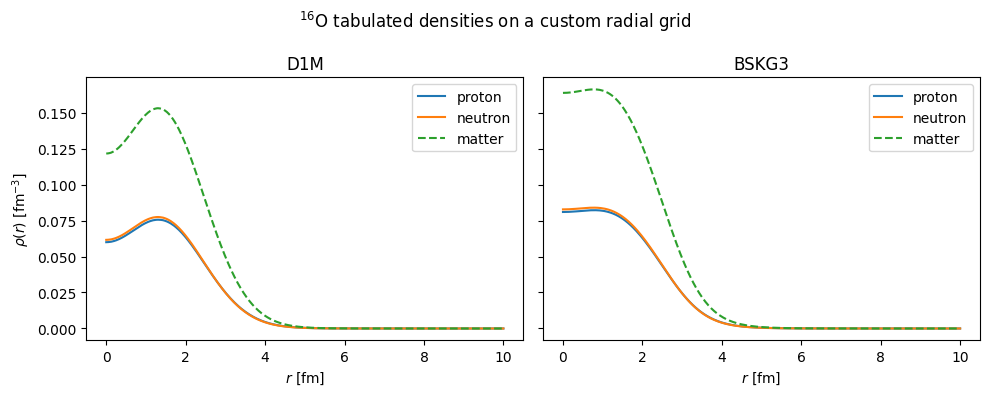

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].plot(r, rho_p_d1m, label="proton")
axes[0].plot(r, rho_n_d1m, label="neutron")
axes[0].plot(r, rho_p_d1m + rho_n_d1m, label="matter", linestyle="--")
axes[0].set_title("D1M")
axes[0].set_xlabel(r"$r$ [fm]")
axes[0].set_ylabel(r"$\rho(r)$ [fm$^{-3}$]")
axes[0].legend()

axes[1].plot(r, rho_p_bskg3, label="proton")
axes[1].plot(r, rho_n_bskg3, label="neutron")
axes[1].plot(r, rho_p_bskg3 + rho_n_bskg3, label="matter", linestyle="--")
axes[1].set_title("BSKG3")
axes[1].set_xlabel(r"$r$ [fm]")
axes[1].legend()

fig.suptitle(r"$^{16}$O tabulated densities on a custom radial grid")
fig.tight_layout()
